In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn faker

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 38.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest

import random

In [15]:
df = pd.read_csv("dataset/students.csv")

df.head()

,Student_ID,Name,Department,Semester,Roll_No
0,1,Jared Morales,ECE,6,8
1,2,Susan Middleton,CSE,4,40
2,3,Joseph Gutierrez,CSE,2,24
3,4,Charles Sullivan PhD,ME,4,35
4,5,Julie Mendoza,ECE,7,40


In [17]:
from faker import Faker

fake = Faker()

students=[]

departments=[
    "CSE",
    "ISE",
    "ECE",
    "ME"
]


for i in range(100):

    students.append([
        i+1,
        fake.name(),
        random.choice(departments),
        random.randint(1,8),
        random.randint(1,50)
    ])


df=pd.DataFrame(
    students,
    columns=[
        "Student_ID",
        "Name",
        "Department",
        "Semester",
        "Roll_No"
    ]
)



In [9]:
import os

# create dataset folder
os.makedirs("dataset", exist_ok=True)

# save file
df.to_csv(
    "dataset/students.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [11]:
import os

os.getcwd()



'C:\\Users\\Student\\Desktop\\Exam seating'

In [13]:
os.listdir()

['.ipynb_checkpoints',
 'dataset',
 'seating_auditor.ipynb',
 'StudentsPerformance.csv']

In [19]:
seats=[]

rows=5
columns=10


seat_number=1


for r in range(rows):

    for c in range(columns):

        seats.append(
            {
                "Seat_No":seat_number,
                "Row":r+1,
                "Column":c+1
            }
        )

        seat_number+=1


seat_df=pd.DataFrame(seats)

seat_df.head()



,Seat_No,Row,Column
0,1,1,1
1,2,1,2
2,3,1,3
3,4,1,4
4,5,1,5


In [27]:
rows=5
columns=10

In [32]:
len(df)

100

In [34]:
len(seats)

50

In [36]:
import numpy as np
import random


# Number of students
student_count = len(df)


# Number of seats per row
columns = 10


# Automatically calculate rows
rows = int(np.ceil(student_count / columns))


# Create seats
seats = []

seat_number = 1


for r in range(rows):
    for c in range(columns):

        seats.append(
            {
                "Seat_No": seat_number,
                "Row": r+1,
                "Column": c+1
            }
        )

        seat_number += 1


print("Students:", student_count)
print("Seats:", len(seats))

Students: 100
Seats: 100


In [38]:
random.shuffle(seats)


seating=[]


for i,student in df.iterrows():

    seating.append(
        [
            student.Student_ID,
            student.Name,
            student.Department,
            seats[i]["Seat_No"],
            seats[i]["Row"],
            seats[i]["Column"]
        ]
    )


seating_df=pd.DataFrame(
    seating,
    columns=[
        "Student_ID",
        "Name",
        "Department",
        "Seat",
        "Row",
        "Column"
    ]
)


seating_df.head()

,Student_ID,Name,Department,Seat,Row,Column
0,1,Nicolas Davis,ISE,72,8,2
1,2,Derek Mcdonald,ME,40,4,10
2,3,Anthony Coleman,ME,79,8,9
3,4,Dr. Shirley Lewis DDS,ECE,13,2,3
4,5,Pamela Freeman,ME,43,5,3


In [40]:
#Create risk calculation function

def calculate_risk(data):

    risk_scores=[]

    for i,row in data.iterrows():

        score=0

        for j,row2 in data.iterrows():

            if i != j:

                # calculate seat distance
                distance = (
                    abs(row["Row"] - row2["Row"]) +
                    abs(row["Column"] - row2["Column"])
                )


                # nearby students
                if distance <= 2:

                    # same department
                    if row["Department"] == row2["Department"]:
                        score += 10


        risk_scores.append(score)


    return risk_scores


In [42]:
seating_df["Risk_Score"] = calculate_risk(seating_df)

seating_df.head()

,Student_ID,Name,Department,Seat,Row,Column,Risk_Score
0,1,Nicolas Davis,ISE,72,8,2,30
1,2,Derek Mcdonald,ME,40,4,10,20
2,3,Anthony Coleman,ME,79,8,9,10
3,4,Dr. Shirley Lewis DDS,ECE,13,2,3,50
4,5,Pamela Freeman,ME,43,5,3,40


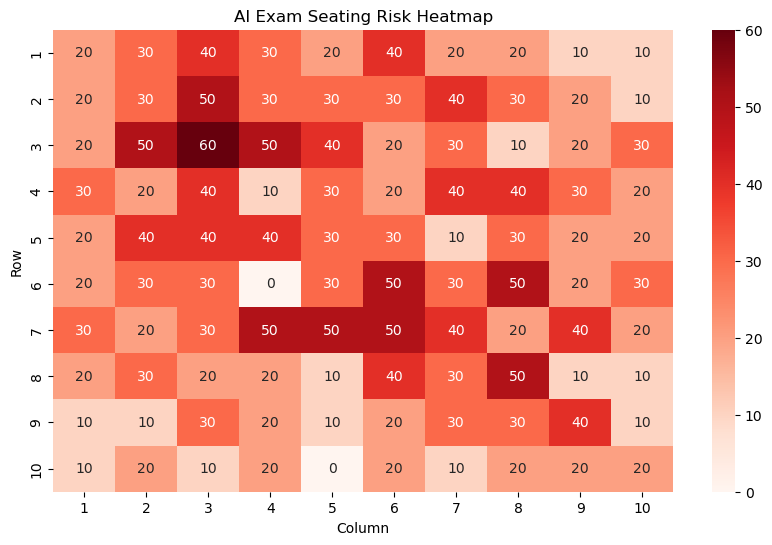

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns


heatmap_data = seating_df.pivot(
    index="Row",
    columns="Column",
    values="Risk_Score"
)


plt.figure(figsize=(10,6))


sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="Reds"
)


plt.title(
    "AI Exam Seating Risk Heatmap"
)


plt.show()

In [46]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [48]:
from sklearn.ensemble import IsolationForest

In [50]:
model = IsolationForest(
    contamination=0.1,
    random_state=42
)


X = seating_df[
    [
        "Row",
        "Column",
        "Risk_Score"
    ]
]


seating_df["AI_Result"] = model.fit_predict(X)


seating_df.head()

,Student_ID,Name,Department,Seat,Row,Column,Risk_Score,AI_Result
0,1,Nicolas Davis,ISE,72,8,2,30,1
1,2,Derek Mcdonald,ME,40,4,10,20,1
2,3,Anthony Coleman,ME,79,8,9,10,1
3,4,Dr. Shirley Lewis DDS,ECE,13,2,3,50,1
4,5,Pamela Freeman,ME,43,5,3,40,1


In [52]:
suspicious_students = seating_df[
    seating_df["AI_Result"] == -1
]


suspicious_students

,Student_ID,Name,Department,Seat,Row,Column,Risk_Score,AI_Result
22,23,Meagan Martinez,ECE,10,1,10,10,-1
32,33,Katie Gonzalez,CSE,100,10,10,20,-1
37,38,Stephanie Daniel,ISE,54,6,4,0,-1
45,46,Frank Owen,CSE,95,10,5,0,-1
47,48,Michael Cox,ECE,78,8,8,50,-1
52,53,Courtney Li,CSE,9,1,9,10,-1
80,81,Riley Mercer,ECE,89,9,9,40,-1
90,91,Sean Ho,CSE,1,1,1,20,-1
93,94,Amy Collins,ECE,23,3,3,60,-1
96,97,Emily Palmer,CSE,91,10,1,10,-1


In [56]:
suspicious_students = seating_df[
    seating_df["AI_Result"] == -1
]


suspicious_students[
    [
        "Name",
        "Department",
        "Seat",
        "Row",
        "Column",
        "Risk_Score",
        "AI_Result"
    ]
]

,Name,Department,Seat,Row,Column,Risk_Score,AI_Result
22,Meagan Martinez,ECE,10,1,10,10,-1
32,Katie Gonzalez,CSE,100,10,10,20,-1
37,Stephanie Daniel,ISE,54,6,4,0,-1
45,Frank Owen,CSE,95,10,5,0,-1
47,Michael Cox,ECE,78,8,8,50,-1
52,Courtney Li,CSE,9,1,9,10,-1
80,Riley Mercer,ECE,89,9,9,40,-1
90,Sean Ho,CSE,1,1,1,20,-1
93,Amy Collins,ECE,23,3,3,60,-1
96,Emily Palmer,CSE,91,10,1,10,-1
